In [ ]:
!pip install -q ultralytics



In [ ]:
import os

cam = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo"

print(os.listdir(cam))

In [ ]:
from ultralytics import YOLO

import yaml

with open("/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/data.yaml") as f:
    print(yaml.safe_load(f))

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to training images
train_img_dir = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/train/images"

# Get all image files
image_files = [
    f for f in os.listdir(train_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select 6 random images
random_images = random.sample(image_files, 6)

# Plot
plt.figure(figsize=(15, 10))

for i, img_name in enumerate(random_images):
    img_path = os.path.join(train_img_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Dataset paths
img_dir = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/train/images"
label_dir = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/train/labels"

images = [f for f in os.listdir(img_dir) if f.endswith((".jpg", ".png", ".jpeg"))]
samples = random.sample(images, 6)

plt.figure(figsize=(15, 10))

for i, img_name in enumerate(samples):
    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, str(int(cls)), (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

plt.tight_layout()
plt.show()

In [ ]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = YOLO("yolov8n.pt")


In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

base = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo"

print(os.path.exists(base))
print(os.path.exists(base + "/train/images"))
print(os.path.exists(base + "/val/images"))
print(os.path.exists(base + "/test/images"))

In [ ]:
import yaml

new_yaml = {
    "path": "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo",
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 10,
    "names": [
        "person",
        "rider",
        "car",
        "bus",
        "truck",
        "bike",
        "motor",
        "traffic light",
        "traffic sign",
        "train"
    ]
}

with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(new_yaml, f)

print("New YAML created!")

In [ ]:
import yaml

yaml_file ="/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/data.yaml"

with open(yaml_file) as f:
    data = yaml.safe_load(f)



print("Number of Classes:", data["nc"])
print()

print("Classes:")
for i, name in enumerate(data["names"]):
    print(f"{i} --> {name}")

In [ ]:


results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=device,
    workers=2,
    verbose=True
)

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/working/runs"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

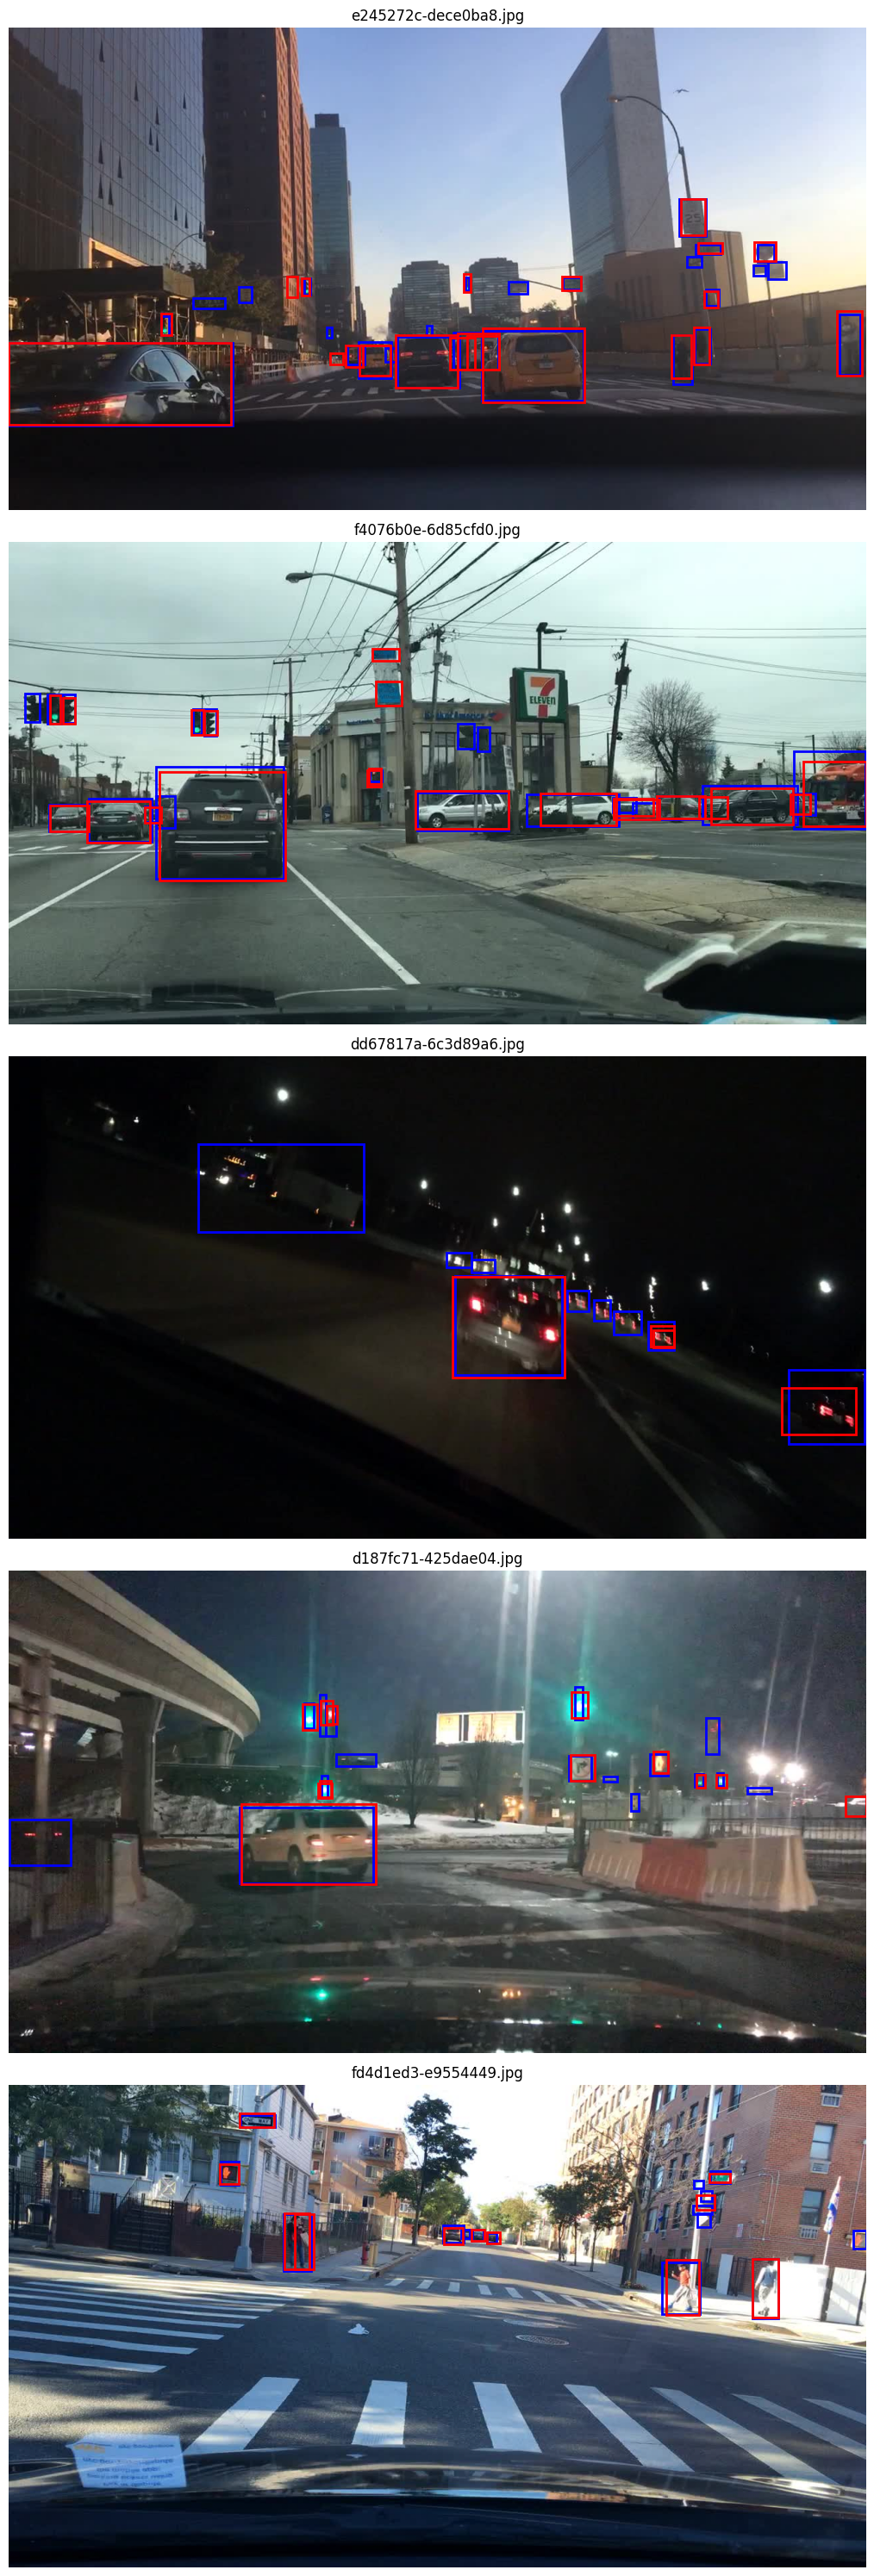

In [36]:
import random
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Paths
test_img_dir = Path("/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/test/images")
test_lbl_dir = Path("/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/test/labels")

# Randomly select 5 images
image_paths = random.sample(list(test_img_dir.glob("*")), 5)

fig, axes = plt.subplots(5, 1, figsize=(12, 30))

for ax, img_path in zip(axes, image_paths):

    # Read image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Run prediction
    result = model.predict(
        source=str(img_path),
        conf=0.25,
        verbose=False
    )[0]

    ax.imshow(img)

    # -------------------------
    # Ground Truth (Blue)
    # -------------------------
    label_path = test_lbl_dir / (img_path.stem + ".txt")

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                bw_pix = bw * w
                bh_pix = bh * h

                rect = patches.Rectangle(
                    (x1, y1),
                    bw_pix,
                    bh_pix,
                    linewidth=2,
                    edgecolor='blue',
                    facecolor='none'
                )
                ax.add_patch(rect)

    # -------------------------
    # Predictions (Red)
    # -------------------------
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()